In [ ]:
import numpy as np
import matplotlib.pyplot as plt
pi = np.pi


In [8]:
J_HP   = np.array([[1,0],[0,0]])
J_VP   = np.array([[0,0],[0,1]])
J_HWP  = np.array([[1,0],[0,-1]])
J_QWP  = np.array([[1,0],[0,-1j]])
J_REFL = np.array([[1,0],[0,-1]])

def J_ROT(theta):
    return np.array([[np.cos(theta),np.sin(theta)],[-np.sin(theta),np.cos(theta)]])

def J_elem_ROT(J,theta):
    return J_ROT(-theta) @ J @ J_ROT(theta)

def v0(phi):
    return np.array([[np.cos(phi)],[np.sin(phi)]])


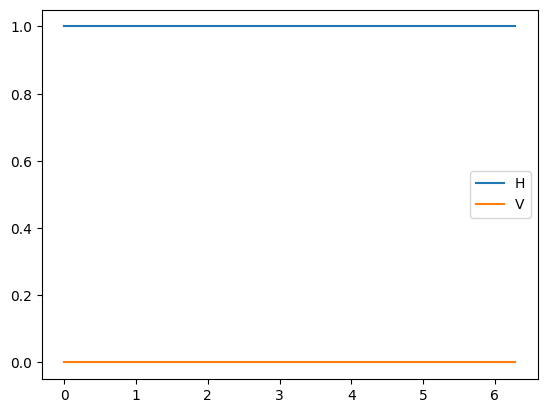

In [27]:

def J_TOT(theta):
    # return J_REFL @ J_ROT(pi/4) @ J_elem_ROT(J_HWP,theta) @ J_REFL @ J_REFL @ J_elem_ROT(J_HWP,theta) @ J_ROT(pi/4) @ J_HP
    return J_REFL @ J_elem_ROT(J_HWP,theta) @ J_REFL @ J_REFL @ J_elem_ROT(J_HWP,theta) @ J_HP
    # return J_REFL @ J_ROT(pi/4) @ J_ROT(pi/4) @ J_HP

J_TOTv = np.vectorize(J_TOT)

thetaarr = np.linspace(0,2*pi,1001)
def vH(theta, phi = 0):
    v = J_TOT(theta) @ v0(phi)
    return v[0][0]

def vV(theta,phi = 0):
    v = J_TOT(theta) @ v0(phi)
    return v[1][0]

vHv = np.vectorize(vH)
vVv = np.vectorize(vV)
plt.plot(thetaarr,vHv(thetaarr), label = 'H')
plt.plot(thetaarr,vVv(thetaarr), label = 'V')
plt.legend()